# KC judge two-source regex experiment v001

## TL;DR

The new v003 judge prompt improved both tested models by exactly one merge
decision and one directional decision over v002, without adding a false merge.
Keep v003.

DeepSeek V4 Flash 0731 at low reasoning was not better than a genuinely
reasoning Pro: Pro scored 57/60 merge decisions versus Flash-low's 56/60.
Flash-low was slightly better directionally (107/120 versus 105/120) and 6.2×
cheaper. Flash-high was worse than Flash-low.

The strongest cost hypothesis is therefore a cascade, not direct replacement:
run Flash-low on every candidate and ask Pro to confirm only Flash double-
`clear_yes` pairs. In this test it reproduced Pro's 57/60 decisions exactly at
an estimated 67% lower judge cost. This is ready for a cross-domain shadow,
not unconditional promotion from two regex sources.

## Context & methods

Two existing Markdown sources were processed through the current pipeline in
an isolated Postgres database: passage cuts and triage, task generation,
granularity, revision, support triage, substance, KC statement, modality,
knowledge, and embeddings. The production `universe` database was never used
for experiment writes.

The resulting 91 KCs produced 326 candidates under the current `.70 / top-6 /
lexical-5` policy. Before seeing judge output, 60 pairs were selected across
similarity strata, balanced by within- versus cross-source origin below 0.90.
Blind gold contains 8 composites and 36 positive directions. Every compared
configuration saw the same item fields and tool schema.

Primary metrics are merge accuracy, false merges, missed merges, directional
accuracy, successful-call coverage, cost, actual reasoning tokens, and repeated
hard-case stability. With only 60 cases, one-case differences are descriptive,
not proof of domain-general superiority.

In [1]:
from pathlib import Path
import json, math, sys
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from universe.judge_cost_eval import candidate_pairs, score_candidate_policy

TEST = json.loads((ROOT / "evals/kc-judge-regex-test-v001.json").read_text())
CORPUS = json.loads((ROOT / "evals/kc-judge-regex-shadow-v001.json").read_text())
CORPUS["cases"] = TEST["cases"]
HARD = json.loads((ROOT / "evals/kc-judge-regex-stability-v001.json").read_text())
PIPELINE = json.loads((ROOT / "evals/kc-judge-regex-pipeline-metrics-v001.json").read_text())

RESULT_PATHS = {
    "Pro current / forced v003": ROOT / "reports/kc-judge-regex-pro-current-v003.json",
    "Pro-high / v002": ROOT / "reports/kc-judge-regex-pro-high-auto-tool-v002.json",
    "Pro-high / v003": ROOT / "reports/kc-judge-regex-pro-high-auto-tool-v003.json",
    "Flash-low / v002": ROOT / "reports/kc-judge-regex-flash-low-v002-auto.json",
    "Flash-low / v003": ROOT / "reports/kc-judge-regex-flash-low-v003-auto.json",
    "Flash-high / v003": ROOT / "reports/kc-judge-regex-flash-high-v003-auto.json",
}
RESULTS = {name: json.loads(path.read_text()) for name, path in RESULT_PATHS.items()}

STABILITY_PATHS = {
    "Pro-high / v003": [
        ROOT / "reports/kc-judge-regex-pro-high-auto-tool-v003.json",
        ROOT / "reports/kc-judge-regex-pro-high-v003-hard-repeat1.json",
        ROOT / "reports/kc-judge-regex-pro-high-v003-hard-repeat2.json",
    ],
    "Flash-low / v003": [
        ROOT / "reports/kc-judge-regex-flash-low-v003-auto.json",
        ROOT / "reports/kc-judge-regex-flash-low-v003-hard-repeat1.json",
        ROOT / "reports/kc-judge-regex-flash-low-v003-hard-repeat2.json",
    ],
}

def merge_prediction(parsed):
    return parsed["verdict_a_to_b"] == "clear_yes" and parsed["verdict_b_to_a"] == "clear_yes"

def directions(parsed):
    return (
        parsed["verdict_a_to_b"] == "clear_yes",
        parsed["verdict_b_to_a"] == "clear_yes",
    )

def by_case(payload):
    return {row["case_id"]: row for row in payload["results"] if row.get("parsed")}

def wilson(successes, total, z=1.96):
    if not total:
        return (None, None)
    p = successes / total
    den = 1 + z*z/total
    center = (p + z*z/(2*total)) / den
    half = z * math.sqrt(p*(1-p)/total + z*z/(4*total*total)) / den
    return center-half, center+half

def exact_paired_p(a_correct, b_correct):
    a_only = sum(x and not y for x, y in zip(a_correct, b_correct))
    b_only = sum(y and not x for x, y in zip(a_correct, b_correct))
    n = a_only + b_only
    if not n:
        return 1.0, a_only, b_only
    tail = sum(math.comb(n, k) for k in range(min(a_only, b_only) + 1)) / 2**n
    return min(1.0, 2 * tail), a_only, b_only

## Data

In [2]:
source_counts = PIPELINE["source_counts"]
pd.DataFrame([
    {"metric": "Markdown sources", "value": 2},
    {"metric": "Materialized passages", "value": sum(x["passages"] for x in source_counts.values())},
    {"metric": "Materialized tasks and parts", "value": sum(x["tasks_materialized"] for x in source_counts.values())},
    {"metric": "Final KCs", "value": sum(x["final_kcs"] for x in source_counts.values())},
    {"metric": "Current-policy candidates", "value": len(CORPUS["candidates"])},
    {"metric": "Blind-gold cases", "value": len(TEST["cases"])},
    {"metric": "Blind-gold composites", "value": sum(c["gold_merge"] for c in TEST["cases"])},
])

,metric,value
0,Markdown sources,2
1,Materialized passages,23
2,Materialized tasks and parts,162
3,Final KCs,91
4,Current-policy candidates,326
5,Blind-gold cases,60
6,Blind-gold composites,8


In [3]:
pipeline_stages = pd.DataFrame(PIPELINE["stages"])
pipeline_stages[["stage", "runs", "items", "errors", "cost", "reasoning_tokens"]].style.format({"cost": "${:.4f}"})

,stage,runs,items,errors,cost,reasoning_tokens
0,passage-cuts,2,2,0,$0.0025,2681
1,passage-triage,2,23,0,$0.0128,1638
2,task-generation,2,18,0,$0.0659,4646
3,task-granularity,2,90,0,$0.0486,17069
4,task-revision,2,162,0,$0.0938,54225
5,task-triage,2,124,0,$0.2343,30576
6,task-substance,2,124,0,$0.0948,53154
7,kc-statement,2,91,0,$0.0390,12360
8,task-modality,10,227,91,$0.0592,0
9,task-knowledge,2,91,0,$0.0380,11624


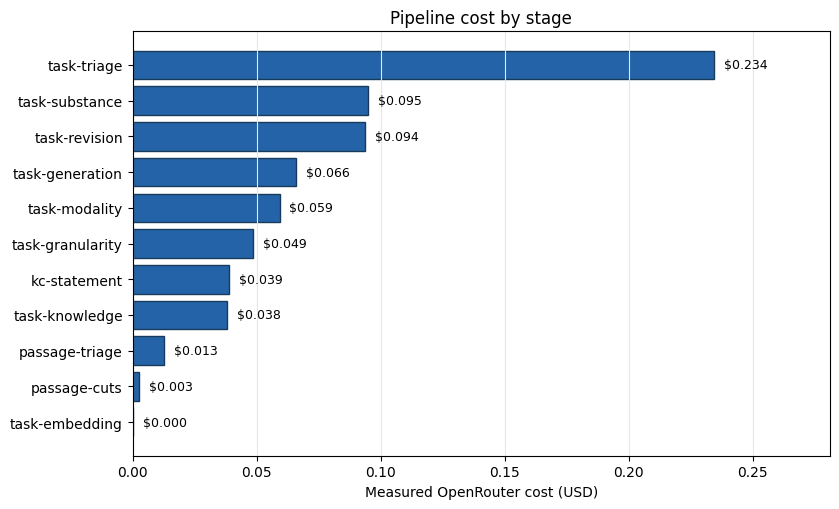

In [4]:
stage_plot = pipeline_stages.sort_values("cost")
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.barh(stage_plot.stage, stage_plot.cost, color="#2463A7", edgecolor="#183B5B")
for y, value in enumerate(stage_plot.cost):
    ax.text(value + .004, y, f"${value:.3f}", va="center", fontsize=9)
ax.set(
    title="Pipeline cost by stage",
    xlabel="Measured OpenRouter cost (USD)",
    ylabel="",
    xlim=(0, max(stage_plot.cost) * 1.2),
)
ax.grid(axis="x", color="#E5E7EB", linewidth=.8)
plt.tight_layout()
plt.savefig(ROOT / "reports/kc-judge-regex-pipeline-cost-v001.png", dpi=180)
plt.show()

## Results — model and prompt configurations

In [5]:
rows = []
for name, payload in RESULTS.items():
    s = payload["scores"]
    successful = [row for row in payload["results"] if row.get("parsed")]
    correct = round((s["merge_accuracy"] or 0) * s["scored_cases"]) if s["scored_cases"] else 0
    lo, hi = wilson(correct, s["scored_cases"])
    rows.append({
        "configuration": name,
        "coverage": s["scored_cases"] / s["cases"],
        "correct_merges": correct,
        "merge_accuracy": s["merge_accuracy"],
        "merge_ci_low": lo,
        "merge_ci_high": hi,
        "false_merges": s["false_merges"],
        "missed_merges": s["missed_merges"],
        "direction_correct": round((s["direction_accuracy"] or 0) * s["scored_cases"] * 2),
        "direction_accuracy": s["direction_accuracy"],
        "cost": s["total_cost"],
        "mean_cost": s["mean_cost_per_call"],
        "reasoning_tokens": s["reasoning_tokens"],
        "providers": ", ".join(f"{k}:{v}" for k, v in s["providers"].items()),
        "mean_latency_s": sum((row.get("duration_ms") or 0) for row in successful) / max(1, len(successful)) / 1000,
    })
configs = pd.DataFrame(rows)
configs.style.format({
    "coverage": "{:.1%}", "merge_accuracy": "{:.1%}",
    "merge_ci_low": "{:.1%}", "merge_ci_high": "{:.1%}",
    "direction_accuracy": "{:.1%}", "cost": "${:.4f}", "mean_cost": "${:.6f}",
    "mean_latency_s": "{:.1f}s",
})

,configuration,coverage,correct_merges,merge_accuracy,merge_ci_low,merge_ci_high,false_merges,missed_merges,direction_correct,direction_accuracy,cost,mean_cost,reasoning_tokens,providers,mean_latency_s
0,Pro current / forced v003,20.0%,9,75.0%,46.8%,91.1%,3,0,19,79.2%,$0.0172,$0.001434,0,Together:12,9.0s
1,Pro-high / v002,100.0%,56,93.3%,84.1%,97.4%,2,2,104,86.7%,$0.1165,$0.001941,65363,Novita:60,17.9s
2,Pro-high / v003,100.0%,57,95.0%,86.3%,98.3%,2,1,105,87.5%,$0.1405,$0.002342,80910,Novita:60,20.9s
3,Flash-low / v002,100.0%,55,91.7%,81.9%,96.4%,3,2,106,88.3%,$0.0223,$0.000372,29540,"BaseTen:4, DigitalOcean:54, Together:2",6.7s
4,Flash-low / v003,100.0%,56,93.3%,84.1%,97.4%,3,1,107,89.2%,$0.0228,$0.000380,34142,"DigitalOcean:43, Fireworks:11, Together:2, BaseTen:4",8.6s
5,Flash-high / v003,100.0%,55,91.7%,81.9%,96.4%,4,1,104,86.7%,$0.0251,$0.000419,38831,"DigitalOcean:53, BaseTen:7",8.6s


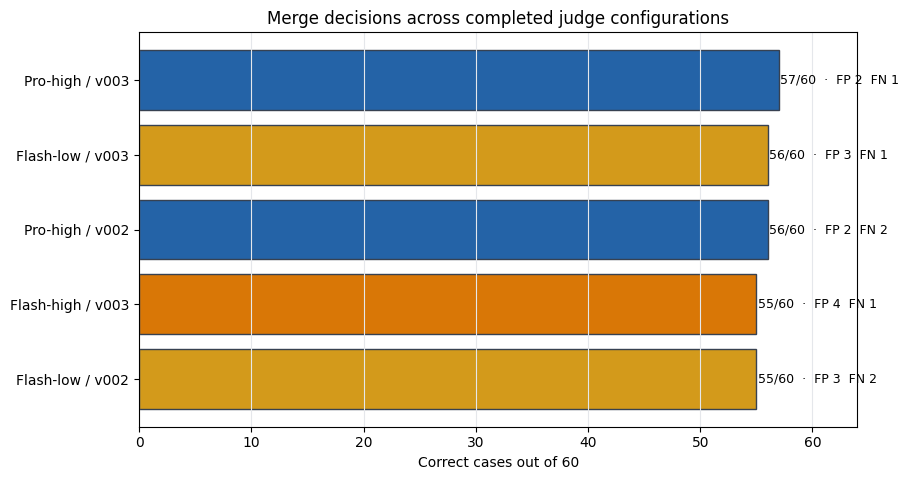

In [6]:
complete = configs[configs.coverage == 1].sort_values("correct_merges")
colors = ["#2463A7" if name.startswith("Pro") else "#D39A1B" if "low" in name else "#D97706" for name in complete.configuration]
fig, ax = plt.subplots(figsize=(9.2, 4.9))
ax.barh(complete.configuration, complete.correct_merges, color=colors, edgecolor="#374151")
for y, (_, row) in enumerate(complete.iterrows()):
    ax.text(row.correct_merges + .15, y, f"{int(row.correct_merges)}/60  ·  FP {int(row.false_merges)}  FN {int(row.missed_merges)}", va="center", fontsize=9)
ax.set(title="Merge decisions across completed judge configurations", xlabel="Correct cases out of 60", ylabel="", xlim=(0, 64))
ax.grid(axis="x", color="#E5E7EB", linewidth=.8)
plt.tight_layout()
plt.savefig(ROOT / "reports/kc-judge-regex-quality-v001.png", dpi=180)
plt.show()

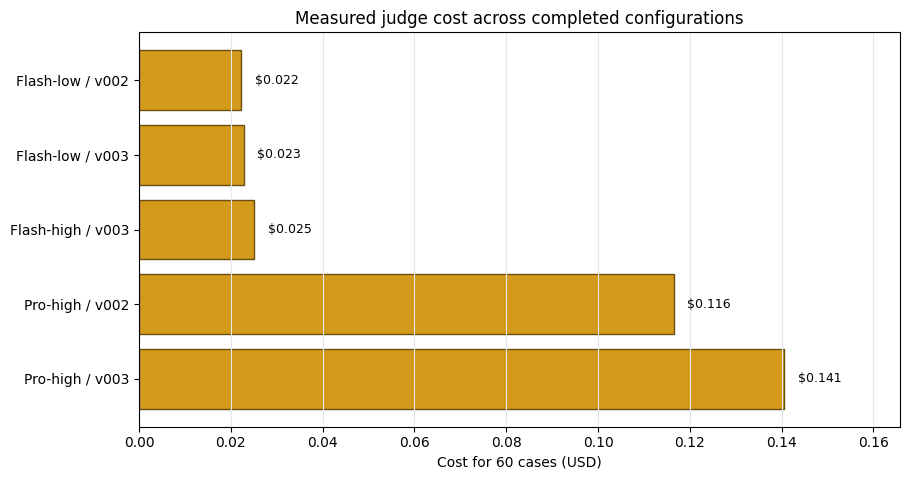

In [7]:
cost_plot = complete.sort_values("cost", ascending=False)
fig, ax = plt.subplots(figsize=(9.2, 4.9))
ax.barh(cost_plot.configuration, cost_plot.cost, color="#D39A1B", edgecolor="#6B4F10")
for y, value in enumerate(cost_plot.cost):
    ax.text(value + .003, y, f"${value:.3f}", va="center", fontsize=9)
ax.set(title="Measured judge cost across completed configurations", xlabel="Cost for 60 cases (USD)", ylabel="", xlim=(0, max(cost_plot.cost) * 1.18))
ax.grid(axis="x", color="#E5E7EB", linewidth=.8)
plt.tight_layout()
plt.savefig(ROOT / "reports/kc-judge-regex-config-cost-v001.png", dpi=180)
plt.show()

In [8]:
def correctness(payload):
    results = by_case(payload)
    return [merge_prediction(results[c["id"]]["parsed"]) == c["gold_merge"] for c in TEST["cases"]]

paired = []
for label, a, b in [
    ("Pro: v003 vs v002", "Pro-high / v003", "Pro-high / v002"),
    ("Flash-low: v003 vs v002", "Flash-low / v003", "Flash-low / v002"),
    ("Pro-v003 vs Flash-low-v003", "Pro-high / v003", "Flash-low / v003"),
]:
    p, a_only, b_only = exact_paired_p(correctness(RESULTS[a]), correctness(RESULTS[b]))
    paired.append({"comparison": label, "first_only_correct": a_only, "second_only_correct": b_only, "exact_p": p})
pd.DataFrame(paired)

,comparison,first_only_correct,second_only_correct,exact_p
0,Pro: v003 vs v002,1,0,1.0
1,Flash-low: v003 vs v002,2,1,1.0
2,Pro-v003 vs Flash-low-v003,1,0,1.0


## Results — prompt effect and hard-case stability

In [9]:
prompt_effect = configs[configs.configuration.isin([
    "Pro-high / v002", "Pro-high / v003", "Flash-low / v002", "Flash-low / v003"
])][["configuration", "correct_merges", "false_merges", "missed_merges", "direction_correct", "cost", "reasoning_tokens"]]
prompt_effect.sort_values("configuration")

,configuration,correct_merges,false_merges,missed_merges,direction_correct,cost,reasoning_tokens
3,Flash-low / v002,55,3,2,106,0.022304,29540
4,Flash-low / v003,56,3,1,107,0.022790,34142
1,Pro-high / v002,56,2,2,104,0.116463,65363
2,Pro-high / v003,57,2,1,105,0.140502,80910


In [10]:
hard_ids = [case["id"] for case in HARD["cases"]]
hard_gold = {case["id"]: (case["gold_a_clear_yes"], case["gold_b_clear_yes"]) for case in HARD["cases"]}
stability_rows = []
for name, paths in STABILITY_PATHS.items():
    runs = []
    categories = []
    for path in paths:
        result = by_case(json.loads(path.read_text()))
        runs.append({case_id: directions(result[case_id]["parsed"]) for case_id in hard_ids})
        categories.append({case_id: (
            result[case_id]["parsed"]["verdict_a_to_b"],
            result[case_id]["parsed"]["verdict_b_to_a"],
        ) for case_id in hard_ids})
    merge_unanimous = sum(len({run[i][0] and run[i][1] for run in runs}) == 1 for i in hard_ids)
    direction_unanimous = sum(len({run[i][d] for run in runs}) == 1 for i in hard_ids for d in (0, 1))
    category_unanimous = sum(len({run[i][d] for run in categories}) == 1 for i in hard_ids for d in (0, 1))
    majority_merge_correct = 0
    majority_direction_correct = 0
    for case_id in hard_ids:
        majority_merge = sum(run[case_id][0] and run[case_id][1] for run in runs) >= 2
        majority_merge_correct += majority_merge == all(hard_gold[case_id])
        for d in (0, 1):
            majority = sum(run[case_id][d] for run in runs) >= 2
            majority_direction_correct += majority == hard_gold[case_id][d]
    stability_rows.append({
        "configuration": name,
        "merge_unanimous": merge_unanimous,
        "merge_cases": 18,
        "direction_unanimous": direction_unanimous,
        "direction_cases": 36,
        "four_level_unanimous": category_unanimous,
        "majority_merge_correct": majority_merge_correct,
        "majority_direction_correct": majority_direction_correct,
    })
stability = pd.DataFrame(stability_rows)
stability

,configuration,merge_unanimous,merge_cases,direction_unanimous,direction_cases,four_level_unanimous,majority_merge_correct,majority_direction_correct
0,Pro-high / v003,16,18,26,36,21,16,22
1,Flash-low / v003,16,18,26,36,19,14,26


## Results — cascade and candidate-volume hypotheses

In [11]:
pro = by_case(RESULTS["Pro-high / v003"])
flash = by_case(RESULTS["Flash-low / v003"])
hybrid = []
for case in TEST["cases"]:
    flash_merge = merge_prediction(flash[case["id"]]["parsed"])
    pro_merge = merge_prediction(pro[case["id"]]["parsed"])
    final = flash_merge and pro_merge
    hybrid.append({"id": case["id"], "gold": case["gold_merge"], "flash_gate": flash_merge, "pro": pro_merge, "final": final})
hybrid_cost = RESULTS["Flash-low / v003"]["scores"]["total_cost"] + sum(row["flash_gate"] for row in hybrid) * RESULTS["Pro-high / v003"]["scores"]["mean_cost_per_call"]
hybrid_summary = {
    "flash_calls": 60,
    "pro_confirmation_calls": sum(row["flash_gate"] for row in hybrid),
    "correct_merges": sum(row["final"] == row["gold"] for row in hybrid),
    "false_merges": sum(row["final"] and not row["gold"] for row in hybrid),
    "missed_merges": sum(not row["final"] and row["gold"] for row in hybrid),
    "measured_cost": hybrid_cost,
    "savings_vs_pro_all": 1 - hybrid_cost / RESULTS["Pro-high / v003"]["scores"]["total_cost"],
}
pd.DataFrame([hybrid_summary]).style.format({"measured_cost": "${:.4f}", "savings_vs_pro_all": "{:.1%}"})

,flash_calls,pro_confirmation_calls,correct_merges,false_merges,missed_merges,measured_cost,savings_vs_pro_all
0,60,10,57,2,1,$0.0462,67.1%


In [12]:
policy_specs = [
    ("Current", .70, 6, 5),
    ("Floor .80 only", .80, 6, 5),
    ("Conservative", .80, 2, 3),
    ("Lean", .85, 2, 3),
    ("Semantic only", .70, 6, 0),
    ("Lexical top-3 only", 1.01, 0, 3),
]
policy_rows = []
for name, floor, cap, lexical_k in policy_specs:
    pairs, _ = candidate_pairs(CORPUS, floor=floor, semantic_cap=cap, lexical_k=lexical_k)
    score = score_candidate_policy(CORPUS, pairs)
    policy_rows.append({
        "policy": name,
        "candidate_calls": len(pairs),
        "reduction_vs_current": 1 - len(pairs) / 326,
        "sample_gold_merges_retained": score["gold_positive_retained"],
        "sample_gold_merges": score["gold_positive_count"],
    })
policies = pd.DataFrame(policy_rows)
policies.style.format({"reduction_vs_current": "{:.1%}"})

,policy,candidate_calls,reduction_vs_current,sample_gold_merges_retained,sample_gold_merges
0,Current,326,0.0%,8,8
1,Floor .80 only,273,16.3%,8,8
2,Conservative,176,46.0%,8,8
3,Lean,163,50.0%,8,8
4,Semantic only,162,50.3%,8,8
5,Lexical top-3 only,160,50.9%,8,8


## Experiment spend

In [13]:
judge_spend_paths = [
    ROOT / "reports/kc-judge-regex-pro-current-v003.json",
    ROOT / "reports/kc-judge-regex-pro-high-auto-tool-v002.json",
    ROOT / "reports/kc-judge-regex-pro-high-auto-tool-v003.json",
    ROOT / "reports/kc-judge-regex-flash-low-v002-auto.json",
    ROOT / "reports/kc-judge-regex-flash-low-v003-auto.json",
    ROOT / "reports/kc-judge-regex-flash-high-v003-auto.json",
    ROOT / "reports/kc-judge-regex-pro-high-v003-hard-repeat1.json",
    ROOT / "reports/kc-judge-regex-pro-high-v003-hard-repeat2.json",
    ROOT / "reports/kc-judge-regex-flash-low-v003-hard-repeat1.json",
    ROOT / "reports/kc-judge-regex-flash-low-v003-hard-repeat2.json",
    ROOT / "reports/kc-judge-regex-flash-low-v003.json",
]
judge_spend = sum(json.loads(path.read_text())["scores"]["total_cost"] for path in judge_spend_paths)
spend = pd.DataFrame([
    {"component": "Two-source pipeline through embeddings", "cost": PIPELINE["totals"]["cost"]},
    {"component": "Judge comparisons, diagnostics, and repeats", "cost": judge_spend},
    {"component": "Total experiment", "cost": PIPELINE["totals"]["cost"] + judge_spend},
])
spend.style.format({"cost": "${:.4f}"})

,component,cost
0,Two-source pipeline through embeddings,$0.6891
1,"Judge comparisons, diagnostics, and repeats",$0.4531
2,Total experiment,$1.1421


In [14]:
analysis = {
    "name": "Concept Universe regex judge experiment analysis v001",
    "pipeline": {
        "sources": 2,
        "final_kcs": 91,
        "candidates": 326,
        "cost": PIPELINE["totals"]["cost"],
        "errors": PIPELINE["totals"]["errors"],
    },
    "configurations": configs.to_dict(orient="records"),
    "paired_tests": paired,
    "prompt_effect": prompt_effect.to_dict(orient="records"),
    "stability": stability.to_dict(orient="records"),
    "hybrid": hybrid_summary,
    "candidate_policies": policies.to_dict(orient="records"),
    "spend": spend.to_dict(orient="records"),
    "recommendation": {
        "prompt": "keep v003",
        "production_forced_pro": "repair routing/tool-choice before using as a baseline",
        "model": "do not claim Flash-low beats Pro-high; shadow a Flash-low rejection gate with Pro confirmation",
        "promotion_gate": "repeat on at least two unrelated domains and require no loss of Pro-positive merges",
    },
}
(ROOT / "reports/kc-judge-regex-analysis-v001.json").write_text(json.dumps(analysis, ensure_ascii=False, indent=2) + "\n")
configs.to_csv(ROOT / "reports/kc-judge-regex-configs-v001.csv", index=False)
analysis["hybrid"]

{'flash_calls': 60,
 'pro_confirmation_calls': 10,
 'correct_merges': 57,
 'false_merges': 2,
 'missed_merges': 1,
 'measured_cost': 0.046206707375999995,
 'savings_vs_pro_all': 0.6711317599423452}

## Takeaways

1. **Keep prompt v003.** It improved both Pro-high and Flash-low by one merge
   and one direction over v002, with no additional false merge.
2. **Do not describe Flash-low as better than Pro-high.** Pro was one case
   better on merges; Flash was two directions better and far cheaper. The
   paired sample is too small for a superiority claim.
3. **Low reasoning was real reasoning.** Flash-low emitted 34,142 reasoning
   tokens across 60 calls. Flash-high spent more, ran much longer, and was
   worse (55/60 versus 56/60).
4. **The current Pro payload is not a valid high-reasoning baseline.** Forced
   tool choice routed 12/60 calls to Together, delivered zero reasoning tokens,
   and failed the other 48. Tool choice `auto` retained structured tool output
   and let Novita deliver 80,910 reasoning tokens with 60/60 coverage.
5. **Shadow the cascade.** Flash-low rejected 50/60 pairs and sent 10 to Pro;
   the final decisions exactly matched Pro on all 60 cases and on all three
   hard-case repetitions, at 67% lower measured judge cost.
6. **Do not promote candidate pruning from this test alone.** The conservative
   policy cut candidate calls 46%, but all eight positives were unusually high
   similarity. Cross-domain positive recall remains the guardrail.